<a href="https://colab.research.google.com/github/MichelaMarini/MATH-6373-PyTorch-tutorial/blob/main/WEEK_8_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retraining YOLOv8 for Object Detection  

## Introduction  

In this tutorial, we will **retrain YOLOv8** on a custom dataset using **Ultralytics YOLO** in PyTorch. YOLOv8 is a state-of-the-art object detection model that provides fast and accurate predictions.  

### Steps Covered:  
1. **Setup and Installation** – Installing the required dependencies.  
2. **Dataset Preparation** – Organizing the dataset in YOLO format (images and annotations in `train`, `val`folders).  
3. **Model Training** – Retraining YOLOv8 on the custom dataset.  
4. **Inference** – Running the trained model on test images to verify performance.  




In [ ]:
pip install opendatasets  #needed to download datasets from kaggle

In [ ]:
!pip install ultralytics #needed to dowload yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

To download datasets from Kaggle, you need to create an account on Kaggle and download your Kaggle API key by following these steps:

1. Go to [Kaggle](https://www.kaggle.com/) and log in.

2. Click on your profile picture (top-right corner) and select Account.

3. Scroll down to the API section.

4. Click Create New Token - this will download a kaggle.json file.

In [ ]:
# Import required libraries
import os
import opendatasets as od
import shutil

# Set Kaggle dataset URL
dataset_url = "https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection"

# Define the target directory for download
download_path = "/content/datasets" # Dataset has to be stored in this path for YoloV8

# Download the dataset
od.download(dataset_url, data_dir=download_path)

# Verify where the dataset was downloaded
os.listdir(download_path)

# Define the correct dataset folder path
dataset_folder = os.path.join(download_path, "fruit-images-for-object-detection")

# Move dataset if needed (sometimes Kaggle downloads it in a subfolder)
if not os.path.exists(dataset_folder):
    subfolder = os.path.join(download_path, os.listdir(download_path)[0])
    shutil.move(subfolder, dataset_folder)

# Paths for train and val folders
train_path = os.path.join(dataset_folder, "train_zip/train")
val_path = os.path.join(dataset_folder, "test_zip/test")

# Check if paths exist
assert os.path.exists(train_path), f"Train path not found: {train_path}"
assert os.path.exists(val_path), f"Validation path not found: {val_path}"

Skipping, found downloaded files in "/content/datasets/fruit-images-for-object-detection" (use force=True to force download)
YAML file saved at /content/datasets/fruit-images-for-object-detection/fruit.yaml



image 1/1 /content/datasets/fruit-images-for-object-detection/test_zip/test/apple_77.jpg: 512x640 5 apples, 14.4ms
Speed: 3.1ms preprocess, 14.4ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to runs/detect/predict


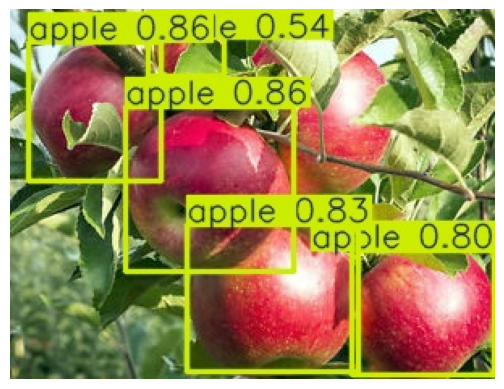

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load the trained YOLO model
model = YOLO("yolov8s.pt")

# Select an image from the test dataset
test_image_path = "datasets/fruit-images-for-object-detection/test_zip/test/apple_77.jpg"

# Run detection
results = model(test_image_path, save=True)

# Load and display the image with detections
annotated_img = cv2.imread("runs/detect/predict/apple_77.jpg")
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


image 1/1 /content/datasets/fruit-images-for-object-detection/test_zip/test/mixed_25.jpg: 480x640 2 bananas, 1 apple, 1 orange, 14.1ms
Speed: 2.5ms preprocess, 14.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict4


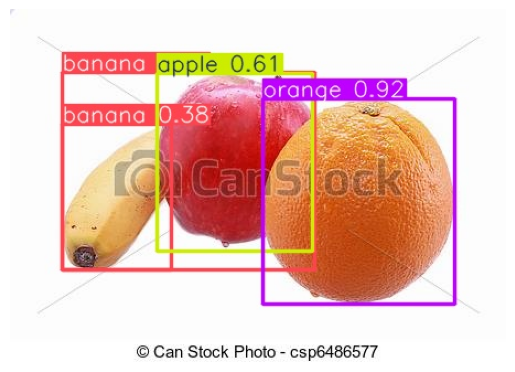

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your trained YOLO model
model = YOLO("yolov8s.pt")  # Replace with your trained model if available

# Select an image from the test dataset
test_image_path = "datasets/fruit-images-for-object-detection/test_zip/test/mixed_25.jpg"

# Run detection
results = model(test_image_path, save=True)

# Load and display the image with detections
annotated_img = cv2.imread("runs/detect/predict3/mixed_25.jpg")
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Steps to Create a New Dataset compatable with YOLOv8

1. **Collect Images**: Gather the images that belong to the dataset. These could be collected from various sources, such as public databases or your own collection.

2. **Annotate Images**: Annotate these images with bounding boxes, segments, or keypoints, depending on the task.

3. **Export Annotations**: Convert these annotations into the YOLO *.txt file format which Ultralytics supports.

4. **Organize Dataset**: Arrange your dataset into the correct folder structure. You should have
```
dataset/
├── train/
│   ├── images/
│   └── labels/
└── val/
    ├── images/
    └── labels/
```

5. **Create a data.yaml File**: In your dataset's root directory, create a data.yaml file that describes the dataset, classes, and other necessary information.

In [ ]:
!pip install xmltodict

In [ ]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [ ]:
def convert_voc_to_yolo(xml_file, img_width, img_height):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    yolo_labels = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in classes:
            continue

        class_id = classes.index(class_name)

        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        bbox_width = (xmax - xmin) / img_width
        bbox_height = (ymax - ymin) / img_height

        yolo_labels.append(f"{class_id} {x_center} {y_center} {bbox_width} {bbox_height}")

    return yolo_labels

In [ ]:
def convert_train_test(root_dir):
    for xml_file in os.listdir(root_dir):
        if xml_file.endswith(".xml"):
            img_file = xml_file.replace(".xml", ".jpg")
            img_path = os.path.join(root_dir, img_file)

            if not os.path.exists(img_path):
                continue

            img = cv2.imread(img_path)
            img_height, img_width, _ = img.shape

            labels = convert_voc_to_yolo(os.path.join(root_dir, xml_file), img_width, img_height)

            txt_filename = os.path.join(root_dir, xml_file.replace(".xml", ".txt"))
            with open(txt_filename, "w") as f:
                f.write("\n".join(labels))

In [ ]:
classes = ["banana", "apple", "orange"]

convert_train_test(train_path)
convert_train_test(val_path)

In [ ]:
# Create fruit.yaml with correct paths
yaml_content = f"""
train: {train_path}
val: {val_path}

nc: 3  # Number of classes
names: ['banana', 'apple', 'orange']
"""

yaml_path = os.path.join(dataset_folder, "fruit.yaml")

# Save the YAML file
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"YAML file saved at {yaml_path}")

In [ ]:
# Train YOLOv8
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8s.pt")

# Train model
model.train(data=yaml_path, epochs=10, imgsz=640, batch=16)

Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/fruit-images-for-object-detection/fruit.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_la

train: Scanning /content/datasets/fruit-images-for-object-detection/train_zip/train.cache... 240 images, 0 backgrounds, 0 corrupt: 100%|██████████| 240/240 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/datasets/fruit-images-for-object-detection/test_zip/test.cache... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<?, ?it/s]


Plotting labels to runs/detect/train9/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train9
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         60        117      0.819      0.829      0.881      0.666



10 epochs completed in 0.028 hours.
Optimizer stripped from runs/detect/train9/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train9/weights/best.pt, 22.5MB

Validating runs/detect/train9/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.28it/s]


                   all         60        117      0.815       0.83      0.881      0.665
                banana         22         40       0.71        0.7      0.759       0.48
                 apple         24         35      0.866      0.886      0.946      0.774
                orange         22         42      0.869      0.905      0.937      0.742
Speed: 0.2ms preprocess, 4.4ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/detect/train9


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bcd341b1fd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /content/datasets/fruit-images-for-object-detection/test_zip/test/apple_77.jpg: 512x640 4 apples, 13.9ms
Speed: 2.8ms preprocess, 13.9ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)


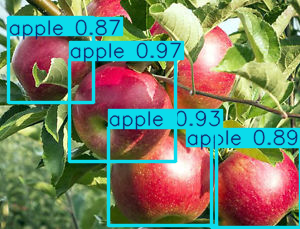

✅ Detection result saved as output_detected.jpg


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load the trained YOLO model
model = YOLO("runs/detect/train9/weights/best.pt")  # Ensure correct model path

# Define image path
image_path = "datasets/fruit-images-for-object-detection/test_zip/test/apple_77.jpg"

# Run inference
results = model(image_path)

# Display results
for r in results:
    r.show()  # Displays image with detections

# Save output image
output_path = "output_detected.jpg"
results[0].save(filename=output_path)
print(f"✅ Detection result saved as {output_path}")



image 1/1 /content/datasets/fruit-images-for-object-detection/test_zip/test/mixed_25.jpg: 480x640 1 banana, 1 apple, 1 orange, 17.4ms
Speed: 3.5ms preprocess, 17.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


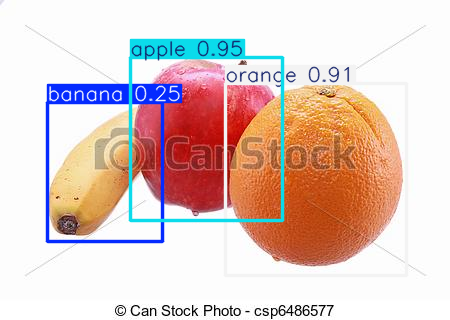

In [ ]:
image_path = "datasets/fruit-images-for-object-detection/test_zip/test/mixed_25.jpg"

# Run inference
results = model(image_path)

# Display results
for r in results:
    r.show()  # Displays image with detections